<a href="https://colab.research.google.com/github/GIRIAYUSH/playing-with-anns/blob/main/notebooks/M6_Activations_and_Parameters_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

torch.manual_seed(42)
np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## M6 · Activations & Parameters

> *"The wrong activation can silently kill half your network."*

A network without activation functions is just a linear transformation — no matter how many layers you stack, it collapses to a single matrix multiply. Activations introduce **non-linearity**, which is what lets networks learn curves, boundaries, and complex structure.

But the *choice* of activation has deep consequences:
- Its **derivative** is what flows backward through backprop
- A zero derivative = dead neuron = that parameter never updates
- A saturated derivative = vanishing gradient = deep layers stop learning

This module builds intuition for every major activation, then puts them into real training to see the difference.

## Activation Functions — The Full Picture

The **derivative** column is what matters for backpropagation. Here's what to notice:

| Activation | Derivative Range | Key Problem | Key Strength |
|---|---|---|---|
| **Sigmoid** | (0, 0.25) | Saturates both ends → vanishing grads | Probabilistic output (0–1) |
| **Tanh** | (0, 1) | Saturates both ends (less bad) | Zero-centered (better than sigmoid) |
| **ReLU** | {0, 1} | Dying ReLU (x<0 → grad=0 forever) | Sparse, fast, default choice |
| **Leaky ReLU** | {0.1, 1} | Small leak, no dying | Fixes dying ReLU |
| **ELU** | Smooth, (−1, ∞) | Slightly slower | Smooth negative, self-normalizing tendencies |
| **GELU** | Smooth | None major | Probabilistic gating, used in Transformers |
| **Swish** | Smooth, non-monotonic | None major | Better than ReLU on deep nets |
| **Softplus** | (0, 1) smooth | Saturates at extremes | Smooth ReLU approximation |

**The core principle:** During backprop, each layer's gradient is multiplied by the activation's derivative at that layer's pre-activation value. If that derivative is 0 (dead ReLU) or near 0 (saturated sigmoid), the upstream gradient signal dies — those weights stop learning.

### All Activation Functions and their gradients

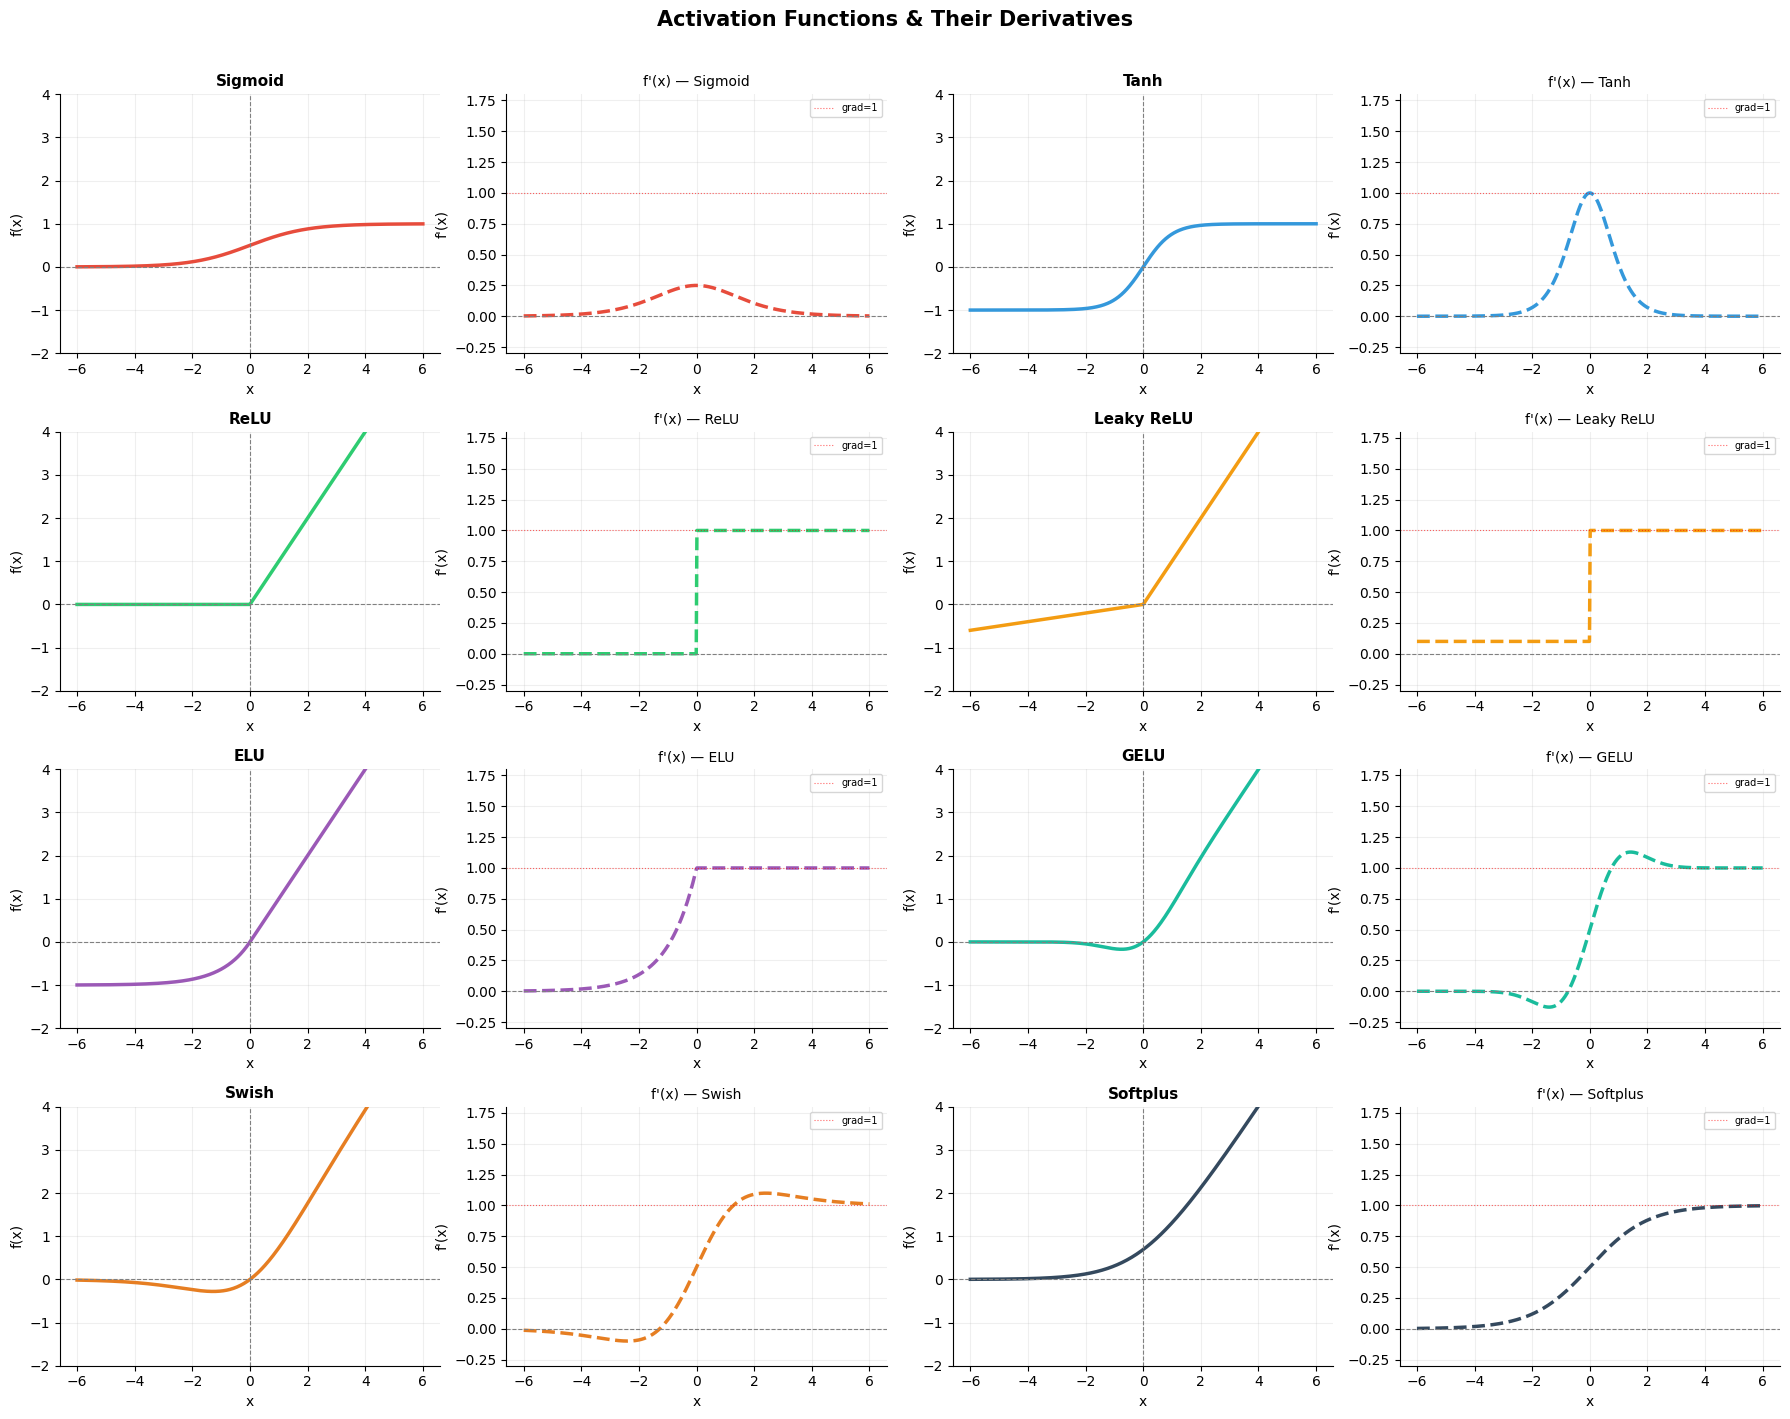

In [2]:
x = torch.linspace(-6, 6, 500, requires_grad=False)

def get_activation_and_grad(name, x_in):
    x_t = x_in.clone().requires_grad_(True)
    activations = {
        'Sigmoid':    torch.sigmoid(x_t),
        'Tanh':       torch.tanh(x_t),
        'ReLU':       F.relu(x_t),
        'Leaky ReLU': F.leaky_relu(x_t, 0.1),
        'ELU':        F.elu(x_t),
        'GELU':       F.gelu(x_t),
        'Swish':      x_t * torch.sigmoid(x_t),
        'Softplus':   F.softplus(x_t),
    }
    out = activations[name]
    out.sum().backward()
    return out.detach().numpy(), x_t.grad.detach().numpy()

act_names = ['Sigmoid', 'Tanh', 'ReLU', 'Leaky ReLU', 'ELU', 'GELU', 'Swish', 'Softplus']
colors    = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e']

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
x_np = x.numpy()

for i, (name, color) in enumerate(zip(act_names, colors)):
    row, col = divmod(i, 2)
    ax_fn   = axes[row][col * 2]
    ax_grad = axes[row][col * 2 + 1]

    fn, grad = get_activation_and_grad(name, x)

    # Activation
    ax_fn.plot(x_np, fn, color=color, linewidth=2.5)
    ax_fn.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax_fn.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax_fn.set_title(f'{name}', fontweight='bold', fontsize=11)
    ax_fn.set_ylim(-2, 4)
    ax_fn.set_ylabel('f(x)')
    ax_fn.set_xlabel('x')
    ax_fn.grid(True, alpha=0.2)

    # Derivative
    ax_grad.plot(x_np, grad, color=color, linewidth=2.5, linestyle='--')
    ax_grad.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax_grad.axhline(1, color='red',  linewidth=0.8, linestyle=':', alpha=0.6, label='grad=1')
    ax_grad.set_title(f"f'(x) — {name}", fontsize=10)
    ax_grad.set_ylim(-0.3, 1.8)
    ax_grad.set_ylabel("f'(x)")
    ax_grad.set_xlabel('x')
    ax_grad.grid(True, alpha=0.2)
    ax_grad.legend(fontsize=7)

plt.suptitle('Activation Functions & Their Derivatives', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## The Dying ReLU Problem

**What happens:** ReLU outputs 0 for any negative input:
$$\text{ReLU}(x) = \max(0, x)$$

Its derivative:
$$\text{ReLU}'(x) = \begin{cases} 1 & x > 0 \\ 0 & x \leq 0 \end{cases}$$

If a neuron's pre-activation is consistently negative (e.g. due to a large negative bias, or after a bad gradient update), the gradient flowing through it is **permanently 0**. The optimizer never updates those weights because:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a} \cdot \underbrace{\text{ReLU}'(z)}_{=\ 0} \cdot x = 0$$

The neuron is **dead** — it outputs 0 for every single input, forever. In wide networks, 10–50% of neurons can die silently.

**Leaky ReLU fix:**
$$\text{LeakyReLU}(x) = \begin{cases} x & x > 0 \\ \alpha x & x \leq 0 \end{cases}, \quad \alpha = 0.01 \text{ or } 0.1$$

The negative slope ($\alpha$) keeps gradient flowing even when a neuron is in the negative zone — it can recover.

> You'll never see a dying ReLU error message. The network trains quietly, just with reduced capacity. Always monitor activation distributions.

Layer         ReLU Dead   Leaky Dead
h1                   39            0
h2                    3            0


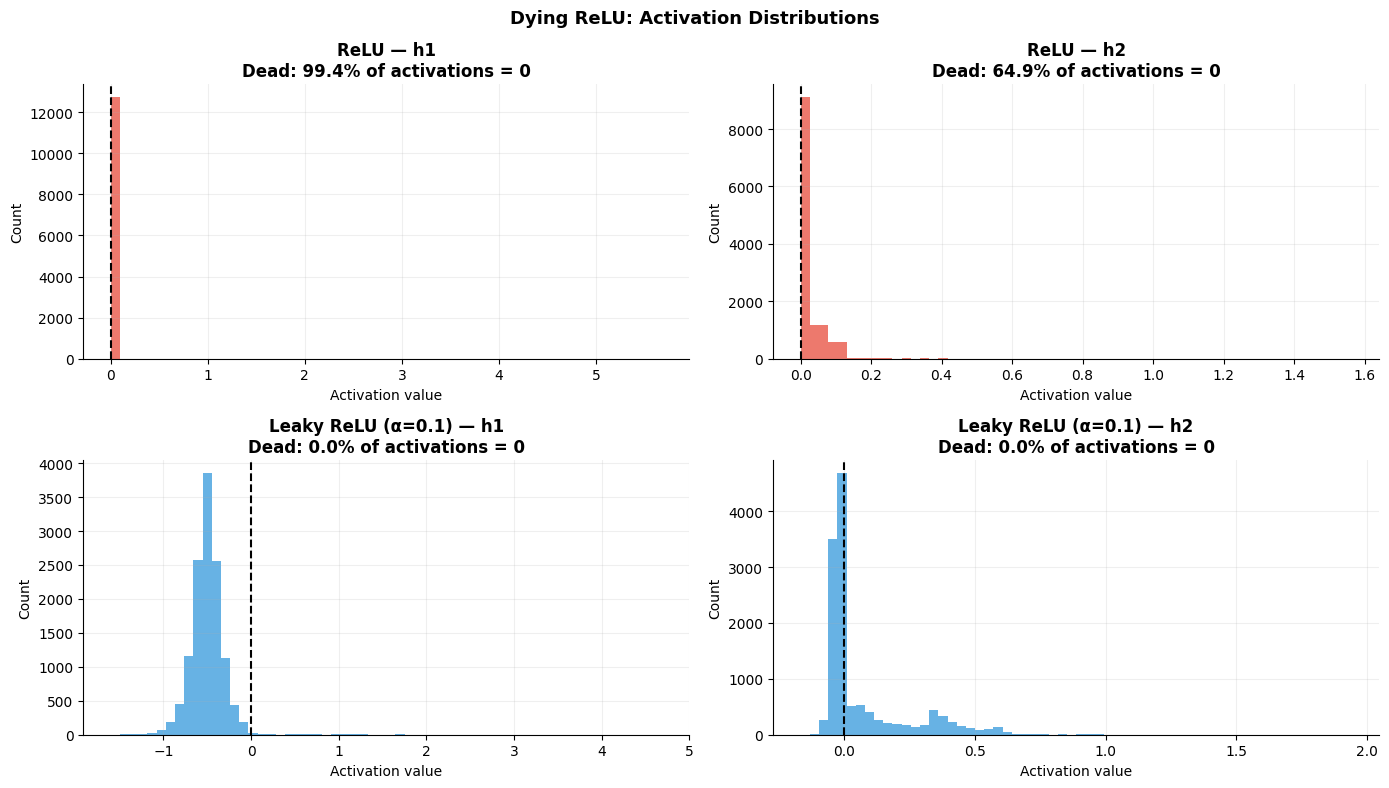

In [3]:
# --- Dying ReLU: neurons permanently stuck at 0 ---

torch.manual_seed(0)

class InspectableNet(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
        self.act = activation
        self.activations_cache = {}

    def forward(self, x):
        h1 = self.act(self.fc1(x))
        h2 = self.act(self.fc2(h1))
        out = self.fc3(h2)
        self.activations_cache = {'h1': h1.detach(), 'h2': h2.detach()}
        return out

def count_dead_neurons(net, x):
    net(x)
    dead = {}
    for layer, acts in net.activations_cache.items():
        # A neuron is dead if it outputs exactly 0 for ALL samples
        dead[layer] = (acts == 0).all(dim=0).sum().item()
    return dead

# XOR-like data — negative values will trigger dying ReLU easily
X = torch.randn(200, 2) * 3  # deliberately wide spread

relu_net   = InspectableNet(nn.ReLU())
leaky_net  = InspectableNet(nn.LeakyReLU(0.1))

# Intentionally bad init: large negative biases → forces neurons into dead zone
with torch.no_grad():
    for p in relu_net.fc1.parameters():
        if p.dim() == 1:  # bias
            p.fill_(-5.0)  # ← strong negative bias kills ReLU neurons
    for p in leaky_net.fc1.parameters():
        if p.dim() == 1:
            p.fill_(-5.0)

dead_relu  = count_dead_neurons(relu_net, X)
dead_leaky = count_dead_neurons(leaky_net, X)

print("=" * 50)
print(f"{'Layer':<10} {'ReLU Dead':>12} {'Leaky Dead':>12}")
print("=" * 50)
for layer in ['h1', 'h2']:
    print(f"{layer:<10} {dead_relu[layer]:>12} {dead_leaky[layer]:>12}")
print("=" * 50)

# Visualise activation distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

relu_net(X)
leaky_net(X)

for row, (net, name) in enumerate([(relu_net, 'ReLU'), (leaky_net, 'Leaky ReLU (α=0.1)')]):
    for col, layer in enumerate(['h1', 'h2']):
        ax = axes[row][col]
        acts = net.activations_cache[layer].numpy().flatten()
        dead_frac = (acts == 0).mean() * 100

        ax.hist(acts, bins=60, color='#e74c3c' if 'ReLU' == name else '#3498db',
                alpha=0.75, edgecolor='none')
        ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
        ax.set_title(f'{name} — {layer}\nDead: {dead_frac:.1f}% of activations = 0',
                     fontweight='bold')
        ax.set_xlabel('Activation value')
        ax.set_ylabel('Count')
        ax.grid(True, alpha=0.2)

plt.suptitle('Dying ReLU: Activation Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Real Training — Why It Matters in Practice

We're now training real networks on a non-linearly separable 2D dataset. Same architecture, same optimizer, **only the activation changes**.

This isolates the activation's effect on:
1. **Speed of convergence** — how fast does loss drop?
2. **Final accuracy** — what's the ceiling?
3. **Stability** — does training stay smooth?

The dataset is two interleaved arcs ("two moons") — a linear classifier cannot separate them. The network must learn a curved decision boundary, which requires composing multiple non-linear transformations across layers.

SyntaxError: unterminated string literal (detected at line 3) (2668927196.py, line 3)

In [5]:
from torch.utils.data import DataLoader, TensorDataset

def make_dataset(n=1000):
    theta = torch.linspace(0, np.pi, n // 2)
    r = 1.0
    # Class 0: upper arc
    x0 = torch.stack([r * torch.cos(theta) + torch.randn(n//2)*0.15,
                      r * torch.sin(theta) + torch.randn(n//2)*0.15], dim=1)
    # Class 1: lower arc, shifted
    x1 = torch.stack([r * torch.cos(theta) + 1 + torch.randn(n//2)*0.15,
                     -r * torch.sin(theta) + torch.randn(n//2)*0.15], dim=1)
    X = torch.cat([x0, x1])
    y = torch.cat([torch.zeros(n//2), torch.ones(n//2)]).long()
    return X, y


In [6]:
X, y = make_dataset(1000)
X_mean, X_std = X.mean(0), X.std(0)
X = (X - X_mean) / X_std

In [7]:
split = 800
X_train, y_train = X[:split], y[:split]
X_test,  y_test  = X[split:], y[split:]


In [8]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

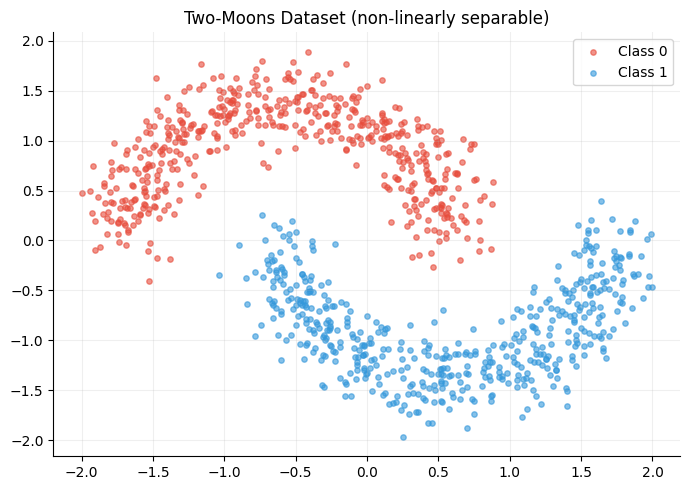

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
for cls, color, label in [(0, '#e74c3c', 'Class 0'), (1, '#3498db', 'Class 1')]:
    mask = y == cls
    ax.scatter(X[mask, 0], X[mask, 1], c=color, s=15, alpha=0.6, label=label)
ax.set_title('Two-Moons Dataset (non-linearly separable)')
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

In [21]:
class ClassifierNet(nn.Module):
    def __init__(self, activation, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(2, hidden), activation]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), activation]
        layers.append(nn.Linear(hidden, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):          # ← same indent level as __init__, NOT inside it
        return self.net(x)


def train_model(activation, name, epochs=40, hidden=64, depth=4):
    torch.manual_seed(42)
    model = ClassifierNet(activation, hidden, depth)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_accs = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        model.eval()
        with torch.no_grad():
            preds = model(X_test).argmax(1)
            acc = (preds == y_test).float().mean().item()
        test_accs.append(acc)      # ← append inside loop, before the print

    # ↓ return and final print are OUTSIDE the loop
    print(f"[{name:>20}]  Final acc: {test_accs[-1]*100:.1f}%  |  Final loss: {train_losses[-1]:.4f}")
    return model, train_losses, test_accs

In [22]:
activation_configs = {
    'Sigmoid':    nn.Sigmoid(),
    'Tanh':       nn.Tanh(),
    'ReLU':       nn.ReLU(),
    'Leaky ReLU': nn.LeakyReLU(0.1),
    'ELU':        nn.ELU(),
    'GELU':       nn.GELU(),
}

In [23]:
results = {}
print("Training...")
for name, act in activation_configs.items():
  results[name] = train_model(act, name)

Training...
[             Sigmoid]  Final acc: 29.0%  |  Final loss: 0.0025
[                Tanh]  Final acc: 33.0%  |  Final loss: 0.0001
[                ReLU]  Final acc: 52.5%  |  Final loss: 0.0000
[          Leaky ReLU]  Final acc: 44.0%  |  Final loss: 0.0000
[                 ELU]  Final acc: 36.5%  |  Final loss: 0.0001
[                GELU]  Final acc: 45.0%  |  Final loss: 0.0001


## Decision Boundaries — What Each Activation Learns

The decision boundary plot reveals the **shape of the function** each activation enables:

- **Sigmoid/Tanh**: Smooth boundaries but slower to converge — saturated neurons slow early training
- **ReLU**: Sharp, piecewise-linear boundaries — fast but may miss smooth curves
- **Leaky ReLU**: Similar to ReLU, more stable through training
- **ELU**: Smooth negative region helps self-normalize → often cleaner boundaries
- **GELU**: Probabilistic soft gating → smooth, well-calibrated boundaries (used in GPT, BERT)

**The loss curves tell you:** how fast each activation transmits useful gradient signal.  
**The decision boundaries tell you:** what kind of function shapes each activation family prefers.

> On simple 2D tasks differences are small. On deep nets (10+ layers), Sigmoid can fail completely while GELU/ReLU thrive.

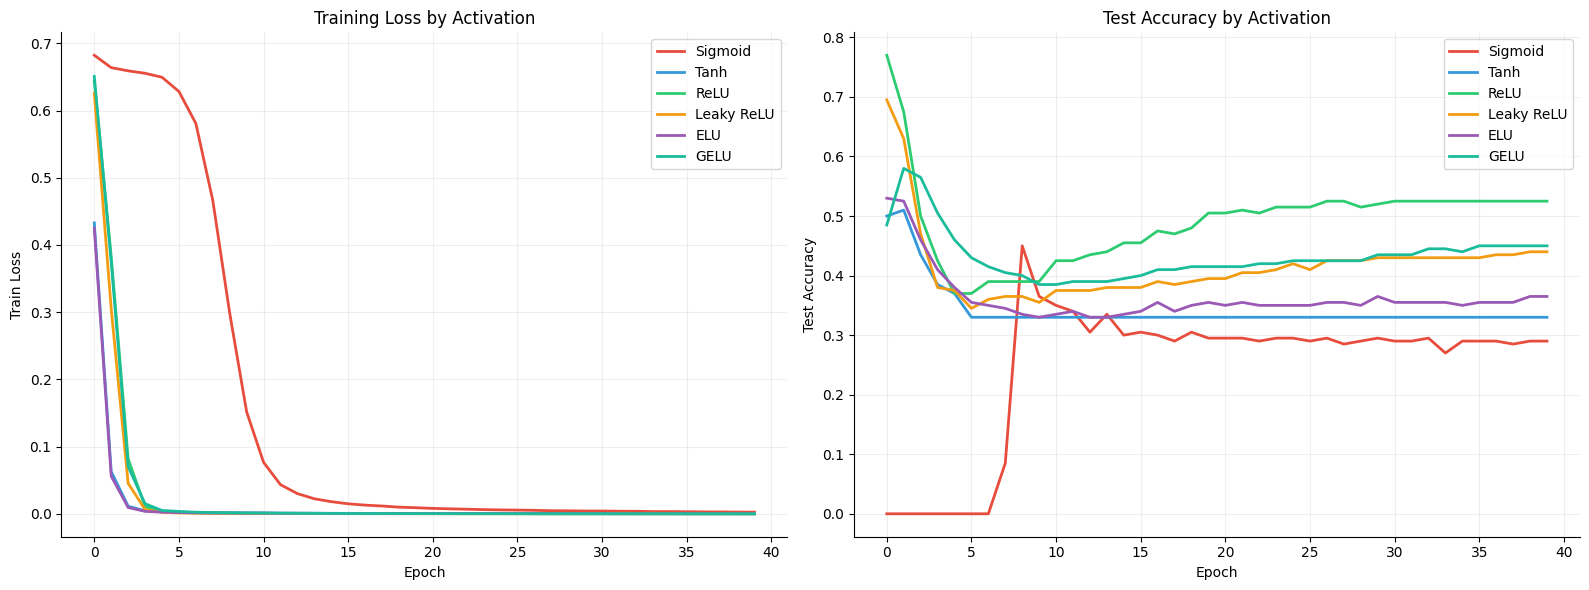

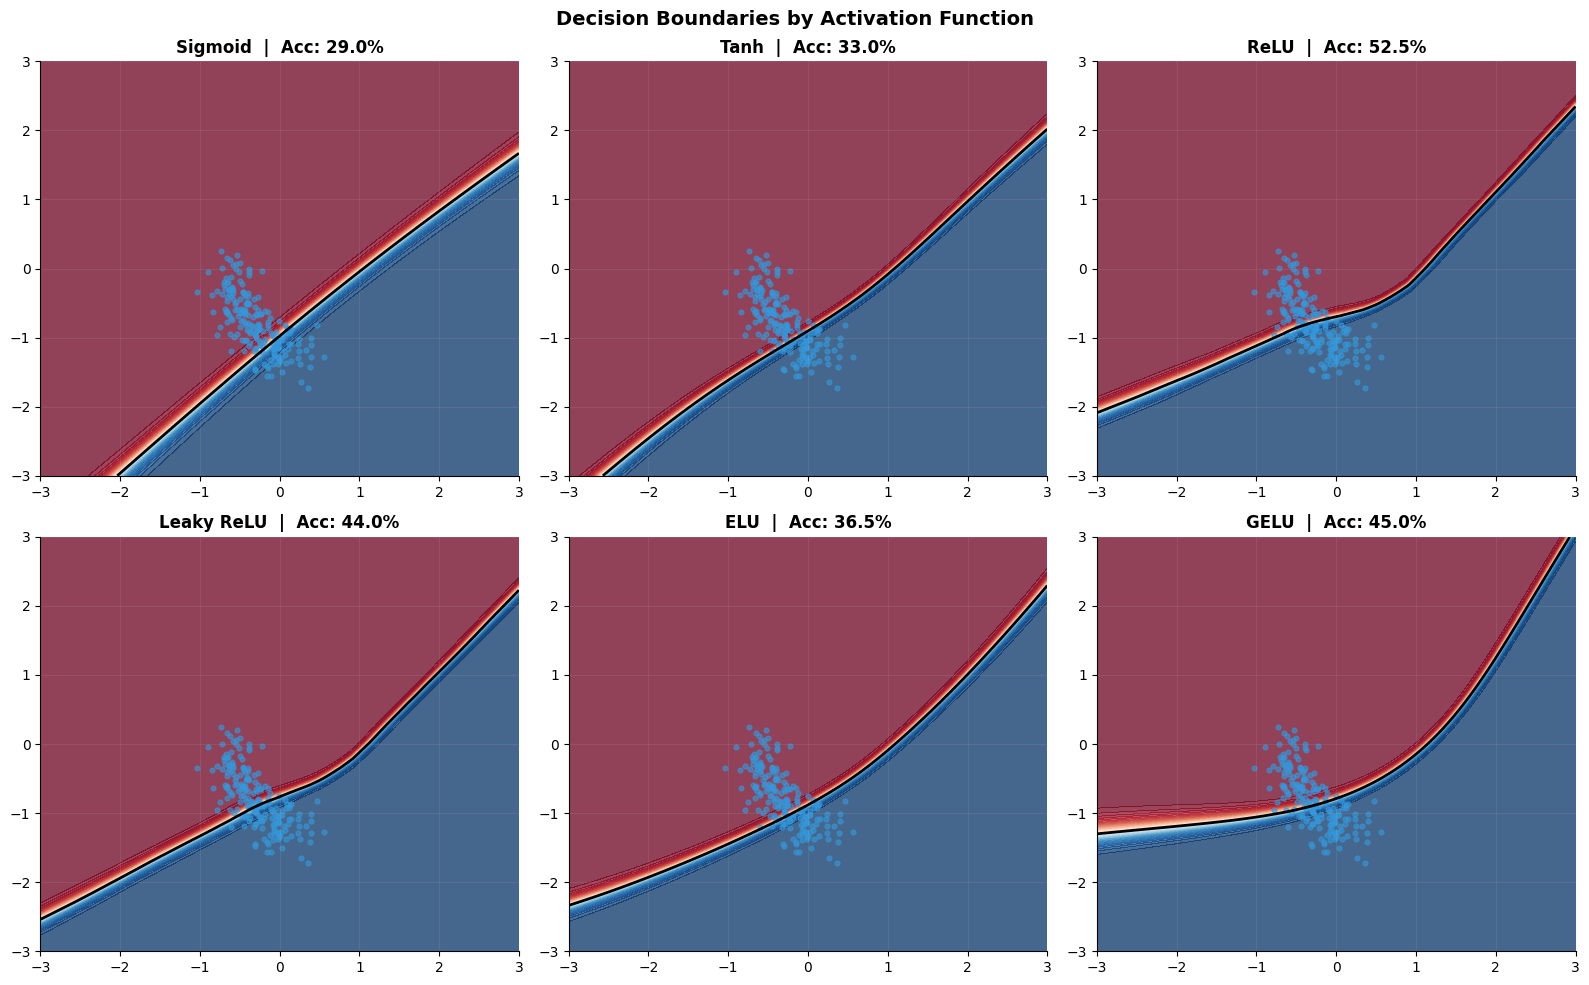

In [24]:
act_colors = {
    'Sigmoid': '#e74c3c', 'Tanh': '#3498db', 'ReLU': '#2ecc71',
    'Leaky ReLU': '#f39c12', 'ELU': '#9b59b6', 'GELU': '#1abc9c'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, (model, losses, accs) in results.items():
    axes[0].plot(losses, label=name, color=act_colors[name], linewidth=2)
    axes[1].plot(accs,   label=name, color=act_colors[name], linewidth=2)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title('Training Loss by Activation'); axes[0].legend(); axes[0].grid(True, alpha=0.2)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Test Accuracy by Activation'); axes[1].legend(); axes[1].grid(True, alpha=0.2)

plt.tight_layout(); plt.show()


# --- Decision boundary plots ---
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid   = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, (model, _, _)) in enumerate(results.items()):
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(grid), dim=1)[:, 1].numpy()
    zz = probs.reshape(xx.shape)

    ax = axes[i]
    ax.contourf(xx, yy, zz, levels=50, cmap='RdBu', alpha=0.75)
    ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2)
    for cls, color in [(0, '#e74c3c'), (1, '#3498db')]:
        mask = y_test == cls
        ax.scatter(X_test[mask, 0], X_test[mask, 1], c=color, s=12, alpha=0.6)
    acc = results[name][2][-1]
    ax.set_title(f'{name}  |  Acc: {acc*100:.1f}%', fontweight='bold')
    ax.grid(True, alpha=0.15)

plt.suptitle('Decision Boundaries by Activation Function', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Width vs Depth — Two Dimensions of Capacity

A network's representational power comes from two axes:

### Width (neurons per layer)
- More neurons = more **parallel features** the layer can detect simultaneously
- A very wide, shallow network is like having many specialists who don't communicate
- Theoretically, a single infinitely wide layer can approximate any function (Universal Approximation Theorem)
- **In practice**: wide-shallow networks need exponentially many neurons for complex functions

### Depth (number of layers)
- More layers = more **hierarchical composition** — early layers detect edges, later layers detect shapes, final layers detect objects
- Depth is *exponentially* more efficient than width for many real-world functions
- But: deeper networks suffer from vanishing gradients, harder optimization

### The trade-off:
| | Wide & Shallow | Narrow & Deep |
|---|---|---|
| **Parameters** | Many | Fewer |
| **Expressiveness** | Limited hierarchy | Rich composition |
| **Optimization** | Easier (shorter gradient path) | Harder (vanishing grads) |
| **Inductive bias** | None | Hierarchical features |
| **Best for** | Simple patterns, tabular data | Images, language, sequences |

> The empirical sweet spot for most problems: **moderate depth (4–12 layers) with moderate width (128–512)** — and tricks like BatchNorm + residual connections to handle the gradient flow.

In [25]:

configs = {
    'Wide & Shallow\n(1 layer, 512 neurons)':  dict(hidden=512, depth=1),
    'Balanced\n(4 layers, 64 neurons)':         dict(hidden=64,  depth=4),
    'Narrow & Deep\n(8 layers, 16 neurons)':    dict(hidden=16,  depth=8),
    'Very Deep\n(12 layers, 32 neurons)':        dict(hidden=32,  depth=12),
}

arch_results = {}
print("Training width/depth configs...")
for name, cfg in configs.items():
    model, losses, accs = train_model(nn.ReLU(), name, epochs=60, **cfg)
    total_params = sum(p.numel() for p in model.parameters())
    arch_results[name] = (model, losses, accs, total_params)
    print(f"  {name.split(chr(10))[0]}: params={total_params:,}  acc={accs[-1]*100:.1f}%")

Training width/depth configs...
[Wide & Shallow
(1 layer, 512 neurons)]  Final acc: 51.5%  |  Final loss: 0.0009
  Wide & Shallow: params=2,562  acc=51.5%
[Balanced
(4 layers, 64 neurons)]  Final acc: 53.0%  |  Final loss: 0.0000
  Balanced: params=12,802  acc=53.0%
[Narrow & Deep
(8 layers, 16 neurons)]  Final acc: 30.5%  |  Final loss: 0.0001
  Narrow & Deep: params=1,986  acc=30.5%
[Very Deep
(12 layers, 32 neurons)]  Final acc: 34.5%  |  Final loss: 0.0000
  Very Deep: params=11,778  acc=34.5%


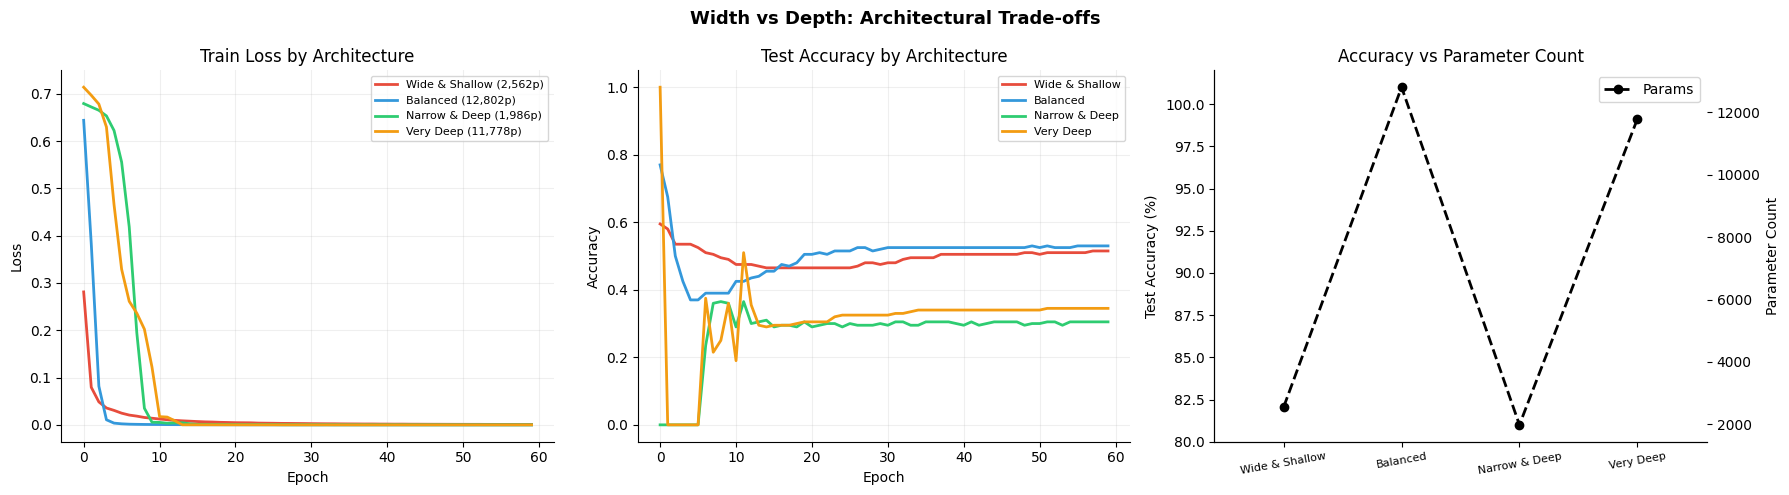

In [26]:
arch_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for (name, (model, losses, accs, n_params)), color in zip(arch_results.items(), arch_colors):
    short = name.split('\n')[0]
    axes[0].plot(losses, label=f'{short} ({n_params:,}p)', color=color, linewidth=2)
    axes[1].plot(accs,   label=f'{short}',                 color=color, linewidth=2)

axes[0].set_title('Train Loss by Architecture'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.2)

axes[1].set_title('Test Accuracy by Architecture'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.2)

# Bar chart: final accuracy vs param count
names_short  = [n.split('\n')[0] for n in arch_results]
final_accs   = [v[2][-1]*100 for v in arch_results.values()]
param_counts = [v[3] for v in arch_results.values()]

ax = axes[2]
bars = ax.bar(range(len(names_short)), final_accs, color=arch_colors, alpha=0.85, edgecolor='black')
ax2 = ax.twinx()
ax2.plot(range(len(names_short)), param_counts, 'k--o', linewidth=2, label='Params')
ax2.set_ylabel('Parameter Count', color='black')
ax.set_xticks(range(len(names_short)))
ax.set_xticklabels(names_short, fontsize=8, rotation=10)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Accuracy vs Parameter Count')
ax.set_ylim(80, 102)
ax2.legend(loc='upper right')

plt.suptitle('Width vs Depth: Architectural Trade-offs', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Gradient Flow — Reading the Health of Your Network

This visualisation shows **how much gradient signal reaches each layer** during backprop. Reading from right to left (last layer → first layer):

- **Healthy network**: gradient norms roughly similar across layers (green bars throughout)
- **Vanishing gradients**: norms shrink exponentially toward early layers (red → green from left to right)
- **Exploding gradients**: norms grow exponentially (gradient clipping needed)

**What to look for:**

| Pattern | Diagnosis | Fix |
|---|---|---|
| Norms drop 100× per layer | Vanishing gradients | Switch to ReLU/GELU, use BatchNorm |
| Norms grow 100× per layer | Exploding gradients | Gradient clipping, careful init |
| First/last ratio ≈ 1 | Healthy flow | Matched |
| Many layers near zero | Dead neurons | Switch activation, check init |

The **first/last ratio** in the title tells you how much signal the earliest layer receives relative to the last. Sigmoid stacks can easily give ratios of `1e-6` — those early weights learn nothing.

> **Pro tip:** Log the gradient norms of your model every few epochs in real projects. Vanishing/exploding gradients are invisible in loss curves until they catastrophically fail.

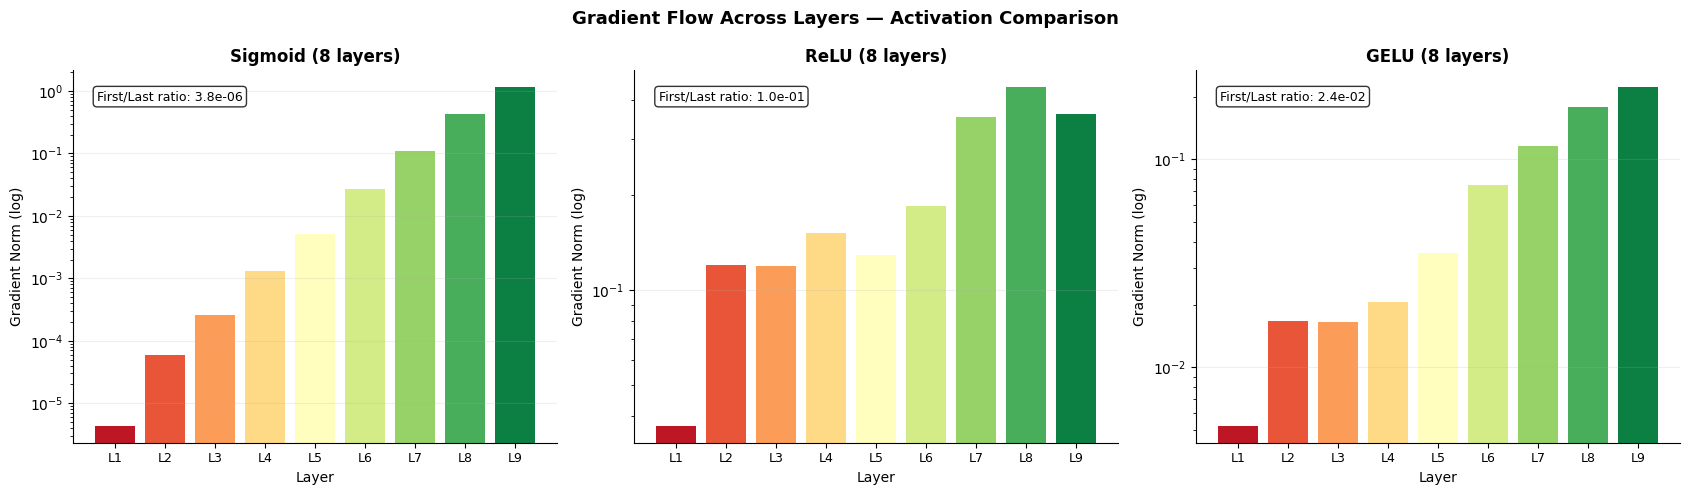

In [27]:
# --- Gradient Magnitudes Across Layers ---

def get_gradient_norms(model, X_sample, y_sample):
    model.train()
    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.SGD(model.parameters(), lr=0.01)
    opt.zero_grad()
    loss = criterion(model(X_sample), y_sample)
    loss.backward()

    norms = {}
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            norms[name] = param.grad.norm().item()
    return norms


X_sample = X_train[:128]
y_sample = y_train[:128]

torch.manual_seed(42)
configs_grad = {
    'Sigmoid (8 layers)': (nn.Sigmoid(), 32, 8),
    'ReLU (8 layers)':    (nn.ReLU(),    32, 8),
    'GELU (8 layers)':    (nn.GELU(),    32, 8),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
grad_colors = ['#e74c3c', '#2ecc71', '#1abc9c']

for ax, (name, (act, h, d)), color in zip(axes, configs_grad.items(), grad_colors):
    torch.manual_seed(42)
    model = ClassifierNet(act, hidden=h, depth=d)
    # Xavier init for fair comparison
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

    norms = get_gradient_norms(model, X_sample, y_sample)
    layer_names = list(norms.keys())
    values      = list(norms.values())

    bar_colors  = plt.cm.RdYlGn(np.linspace(0.05, 0.95, len(values)))
    bars        = ax.bar(range(len(values)), values, color=bar_colors, edgecolor='none')
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels([f'L{i+1}' for i in range(len(values))], fontsize=9)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Gradient Norm (log)')
    ax.set_yscale('log')
    ax.set_title(f'{name}', fontweight='bold')
    ax.grid(True, alpha=0.2, axis='y')

    # Annotate ratio first/last
    if len(values) >= 2:
        ratio = values[0] / (values[-1] + 1e-12)
        ax.text(0.05, 0.92, f'First/Last ratio: {ratio:.1e}',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Gradient Flow Across Layers — Activation Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Weight Initialisation — Starting Point Matters More Than You Think

The initial weights determine the **activation distribution at layer 0**. That distribution propagates forward (affecting what activations look like in all layers) and backward (affecting how gradients flow before any learning happens).

### The Four Strategies:

**Zeros Init**
$$W = 0$$
Every neuron computes the same thing → same gradient → weights update identically → the network is permanently stuck as a 1-neuron model. Called the **symmetry problem**.

**Random Small** ($\sigma = 0.01$)
Activations collapse to near-zero → vanishing gradients from step 1. Learning is extremely slow.

**Random Large** ($\sigma = 2.0$)
Activations saturate → for Sigmoid/Tanh, gradients vanish immediately. For ReLU, many neurons might survive but it's unstable.

**Xavier / Glorot** (for Sigmoid/Tanh)
$$W \sim \mathcal{U}\left(-\sqrt{\frac{6}{n_{in}+n_{out}}},\ \sqrt{\frac{6}{n_{in}+n_{out}}}\right)$$
Designed so that variance of activations is preserved across layers. Derived by keeping $\text{Var}(y) = \text{Var}(x)$ assuming linear activations.

**He / Kaiming** (for ReLU)
$$W \sim \mathcal{N}\left(0,\ \sqrt{\frac{2}{n_{in}}}\right)$$
ReLU kills ~50% of neurons, so we need 2× the variance to compensate. The factor of 2 comes from the fact that only the positive half of the distribution passes through.

| Init | Best For | Problem |
|---|---|---|
| Zeros | — | Symmetry; never use |
| Random Small | — | Vanishing activations |
| Xavier | Sigmoid, Tanh | Assumes linear; bad for ReLU |
| He / Kaiming | **ReLU, Leaky ReLU** | Default for modern networks |

In [28]:
# --- Weight Init: zeros / random / Xavier / He ---

def init_model(init_name, activation, hidden=64, depth=5):
    torch.manual_seed(42)
    model = ClassifierNet(activation, hidden, depth)

    for name, param in model.named_parameters():
        if param.dim() < 2:   # bias
            nn.init.zeros_(param)
            continue
        if init_name == 'Zeros':
            nn.init.zeros_(param)
        elif init_name == 'Random Small':
            nn.init.normal_(param, 0, 0.01)
        elif init_name == 'Random Large':
            nn.init.normal_(param, 0, 2.0)
        elif init_name == 'Xavier':
            nn.init.xavier_uniform_(param)
        elif init_name == 'He (Kaiming)':
            nn.init.kaiming_normal_(param, nonlinearity='relu')
    return model


init_names = ['Zeros', 'Random Small', 'Random Large', 'Xavier', 'He (Kaiming)']
init_colors = ['#95a5a6', '#e74c3c', '#e67e22', '#3498db', '#2ecc71']

init_results = {}
print("Training with different initialisations (ReLU)...")
for iname in init_names:
    model = init_model(iname, nn.ReLU())
    _, losses, accs = train_model(nn.ReLU(), iname, epochs=50)
    # re-do with our init (train_model re-inits internally — let's do it manually)
    torch.manual_seed(42)
    model  = init_model(iname, nn.ReLU())
    opt    = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit   = nn.CrossEntropyLoss()
    losses, accs = [], []
    for epoch in range(50):
        model.train()
        ep_loss = 0
        for xb, yb in train_loader:
            opt.zero_grad()
            l = crit(model(xb), yb); l.backward(); opt.step()
            ep_loss += l.item()
        losses.append(ep_loss / len(train_loader))
        model.eval()
        with torch.no_grad():
            acc = (model(X_test).argmax(1) == y_test).float().mean().item()
        accs.append(acc)
    init_results[iname] = (losses, accs)
    print(f"  {iname:>15}: final acc={accs[-1]*100:.1f}%  loss={losses[-1]:.4f}")

Training with different initialisations (ReLU)...
[               Zeros]  Final acc: 53.0%  |  Final loss: 0.0000
            Zeros: final acc=0.0%  loss=0.6610
[        Random Small]  Final acc: 53.0%  |  Final loss: 0.0000
     Random Small: final acc=28.5%  loss=0.0000
[        Random Large]  Final acc: 53.0%  |  Final loss: 0.0000
     Random Large: final acc=88.5%  loss=0.0000
[              Xavier]  Final acc: 53.0%  |  Final loss: 0.0000
           Xavier: final acc=46.5%  loss=0.0000
[        He (Kaiming)]  Final acc: 53.0%  |  Final loss: 0.0000
     He (Kaiming): final acc=77.5%  loss=0.0000


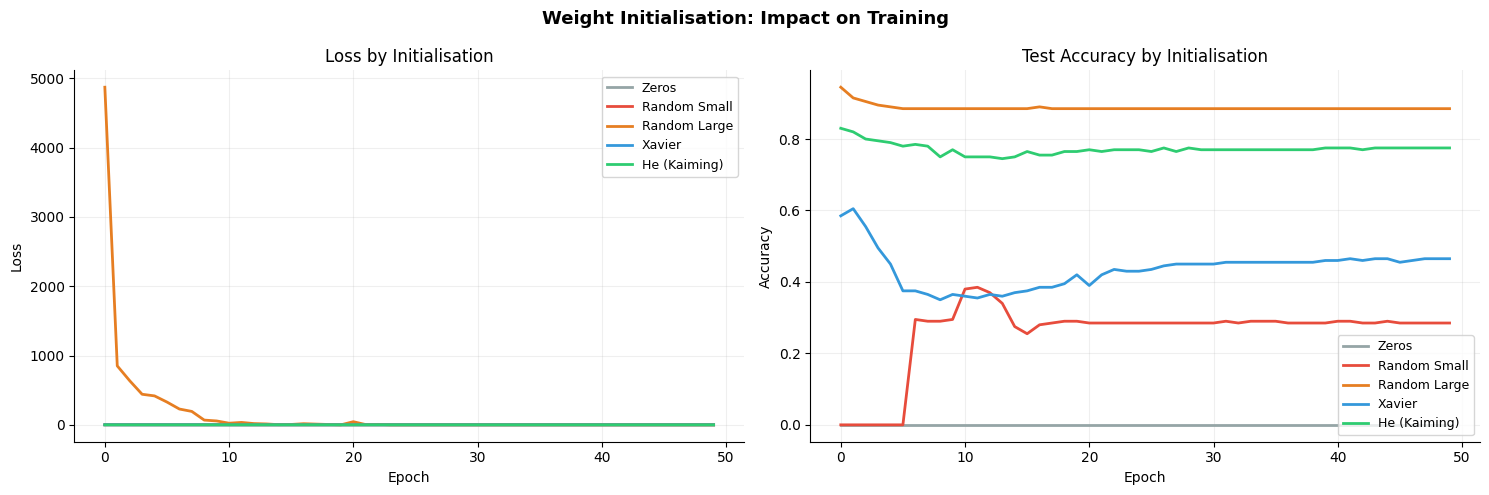

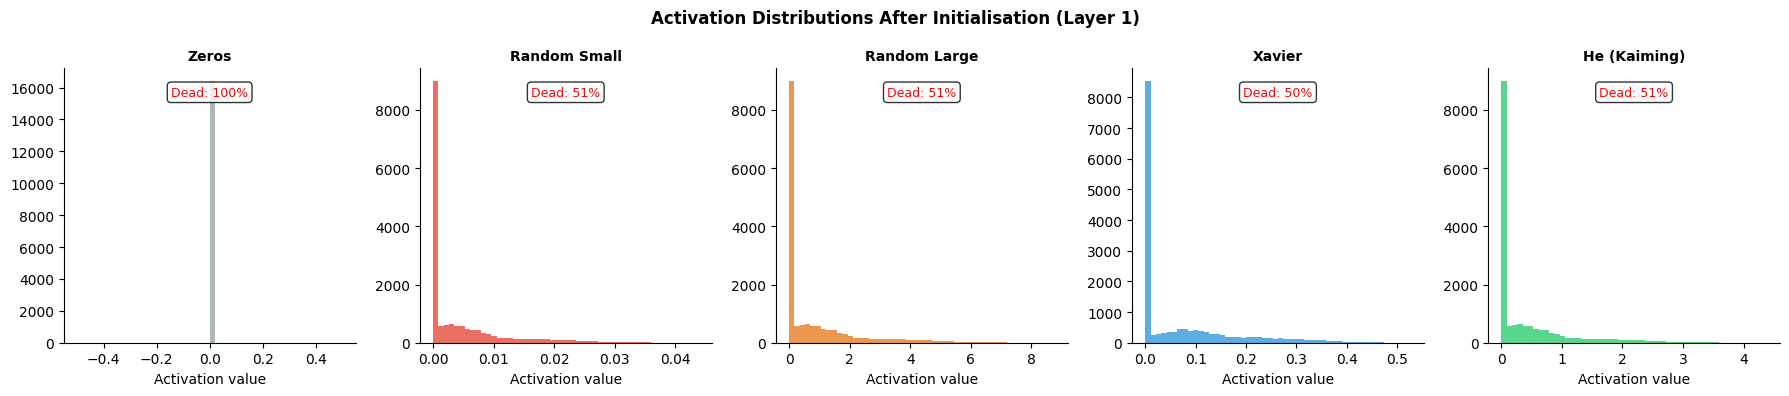

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for (iname, (losses, accs)), color in zip(init_results.items(), init_colors):
    axes[0].plot(losses, label=iname, color=color, linewidth=2)
    axes[1].plot(accs,   label=iname, color=color, linewidth=2)

axes[0].set_title('Loss by Initialisation'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

axes[1].set_title('Test Accuracy by Initialisation'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2)

plt.suptitle('Weight Initialisation: Impact on Training', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


# Visualise initial activation distributions
fig, axes = plt.subplots(1, len(init_names), figsize=(18, 4))
X_probe = X_train[:256]

for ax, iname, color in zip(axes, init_names, init_colors):
    model = init_model(iname, nn.ReLU())
    with torch.no_grad():
        # Pass through first layer
        h = F.relu(model.net[0](X_probe)).numpy().flatten()
    ax.hist(h, bins=50, color=color, alpha=0.8, edgecolor='none')
    ax.set_title(f'{iname}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Activation value')
    dead_pct = (h == 0).mean() * 100
    ax.text(0.5, 0.9, f'Dead: {dead_pct:.0f}%', transform=ax.transAxes,
            ha='center', fontsize=9, color='red' if dead_pct > 20 else 'green',
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.suptitle('Activation Distributions After Initialisation (Layer 1)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 🗺️ When to Use Which Activation — The Decision Guide

Here's the practical guide used by practitioners:

---

### 🔵 ReLU — The Default
**Use when:** CNNs, tabular data, any hidden layer where you want a fast, reliable baseline  
**Avoid when:** Very deep nets without BatchNorm, negative-value outputs matter  
**Init:** He / Kaiming  
```python
nn.ReLU()   +   nn.init.kaiming_normal_(p, nonlinearity='relu')
```

---

### 🟠 Leaky ReLU / ELU — ReLU with Insurance
**Use when:** You're seeing dead neurons, or training a deep net that keeps dying  
**ELU advantage:** Smooth + negative saturation → self-normalizing tendencies  
**Init:** He for Leaky ReLU, Xavier for ELU  
```python
nn.LeakyReLU(0.1)    # or nn.ELU()
```

---

### 🟢 GELU — The Modern Standard
**Use when:** Transformers, BERT, GPT, any attention-based architecture  
**Why:** Smooth probabilistic gating — "how much should this neuron contribute?" — maps well to attention mechanisms  
**Init:** Xavier  
```python
nn.GELU()   # default in nn.TransformerEncoderLayer
```

---

### 🔴 Sigmoid — Output Layer Only
**Use when:** Binary classification output (not hidden layers!)  
**Never:** Hidden layers in deep networks → vanishing gradients  
```python
# Output only:
nn.Linear(hidden, 1)  →  nn.Sigmoid()
# Or just use BCEWithLogitsLoss and skip the sigmoid
```

---

### 🟡 Tanh — RNNs & Normalised Outputs
**Use when:** Recurrent networks (LSTM cell gates), outputs need range (−1, 1)  
**Why:** Zero-centered (unlike Sigmoid) → better gradient flow than Sigmoid  
```python
nn.Tanh()   # used internally by nn.LSTM
```

---

### Quick Reference Table:
| Activation | Hidden Layers | Output Layer | Transformers | RNNs | CNNs |
|---|---|---|---|---|---|
| ReLU       | ✅ Default    | ❌           | ⚠️ OK        | ⚠️   | ✅   |
| Leaky ReLU | ✅ Good       | ❌           | ⚠️           | ⚠️   | ✅   |
| GELU       | ✅ Great      | ❌           | ✅ Default   | ✅   | ✅   |
| Sigmoid    | ❌ Avoid      | ✅ Binary    | ❌           | ❌   | ❌   |
| Tanh       | ⚠️ Shallow   | ✅ (−1,1)   | ❌           | ✅   | ❌   |
| ELU        | ✅ Good       | ❌           | ⚠️           | ✅   | ✅   |

Benchmarking activations...
       Sigmoid: 29.0% acc | >90% at epoch 60
          Tanh: 29.0% acc | >90% at epoch 60
          ReLU: 60.5% acc | >90% at epoch 60
    Leaky ReLU: 58.0% acc | >90% at epoch 60
           ELU: 29.0% acc | >90% at epoch 60
          GELU: 32.0% acc | >90% at epoch 60


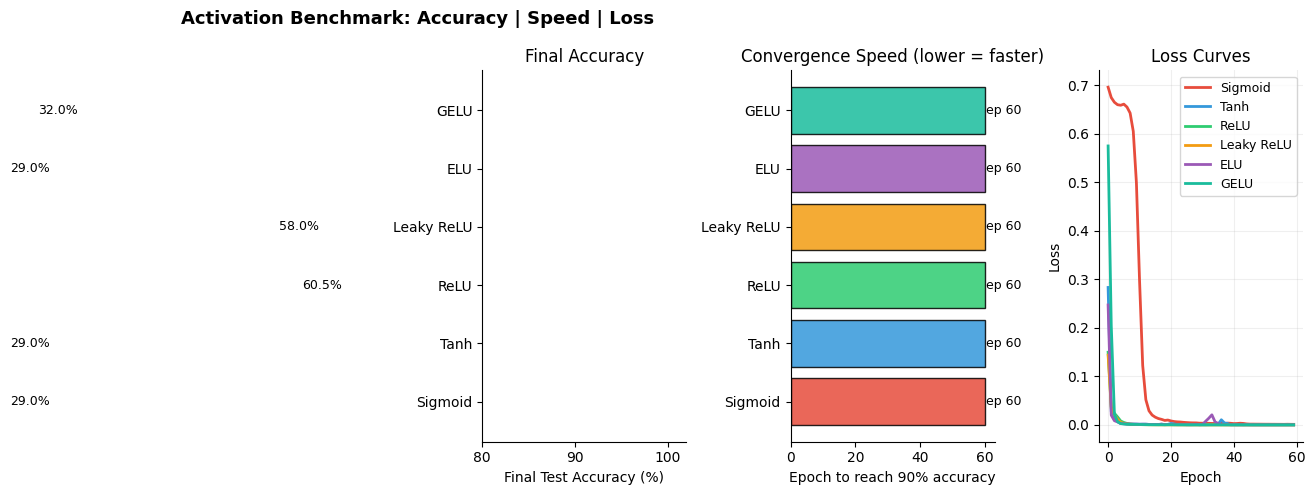

In [30]:
# --- Activation benchmark: accuracy + convergence speed ---

benchmark = {
    'Sigmoid':    nn.Sigmoid(),
    'Tanh':       nn.Tanh(),
    'ReLU':       nn.ReLU(),
    'Leaky ReLU': nn.LeakyReLU(0.1),
    'ELU':        nn.ELU(),
    'GELU':       nn.GELU(),
}

bench_results = {}
print("Benchmarking activations...")
for name, act in benchmark.items():
    torch.manual_seed(42)
    model = ClassifierNet(act, hidden=64, depth=5)
    # Proper init per activation
    for p in model.parameters():
        if p.dim() > 1:
            if name in ['ReLU', 'Leaky ReLU']:
                nn.init.kaiming_normal_(p, nonlinearity='relu')
            else:
                nn.init.xavier_uniform_(p)

    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit  = nn.CrossEntropyLoss()
    losses, accs = [], []

    for epoch in range(60):
        model.train()
        ep = 0
        for xb, yb in train_loader:
            opt.zero_grad(); l = crit(model(xb), yb); l.backward(); opt.step()
            ep += l.item()
        losses.append(ep / len(train_loader))
        model.eval()
        with torch.no_grad():
            acc = (model(X_test).argmax(1) == y_test).float().mean().item()
        accs.append(acc)

    # Convergence speed: epoch where acc first exceeds 90%
    thresh_epoch = next((i for i, a in enumerate(accs) if a > 0.90), 60)
    bench_results[name] = dict(losses=losses, accs=accs,
                                final_acc=accs[-1], conv_epoch=thresh_epoch)
    print(f"  {name:>12}: {accs[-1]*100:.1f}% acc | >90% at epoch {thresh_epoch}")


# Summary plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names  = list(bench_results.keys())
f_accs = [bench_results[n]['final_acc']*100 for n in names]
c_eps  = [bench_results[n]['conv_epoch'] for n in names]
bcolors = [act_colors.get(n, '#888') for n in names]

# Accuracy bars
axes[0].barh(names, f_accs, color=bcolors, alpha=0.85, edgecolor='black')
axes[0].set_xlabel('Final Test Accuracy (%)')
axes[0].set_title('Final Accuracy')
axes[0].set_xlim(80, 102)
for i, v in enumerate(f_accs):
    axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

# Convergence speed bars
axes[1].barh(names, c_eps, color=bcolors, alpha=0.85, edgecolor='black')
axes[1].set_xlabel('Epoch to reach 90% accuracy')
axes[1].set_title('Convergence Speed (lower = faster)')
for i, v in enumerate(c_eps):
    axes[1].text(v + 0.2, i, f'ep {v}', va='center', fontsize=9)

# Loss curves
for name in names:
    axes[2].plot(bench_results[name]['losses'], label=name,
                 color=act_colors.get(name, '#888'), linewidth=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].set_title('Loss Curves'); axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.2)

plt.suptitle('Activation Benchmark: Accuracy | Speed | Loss', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

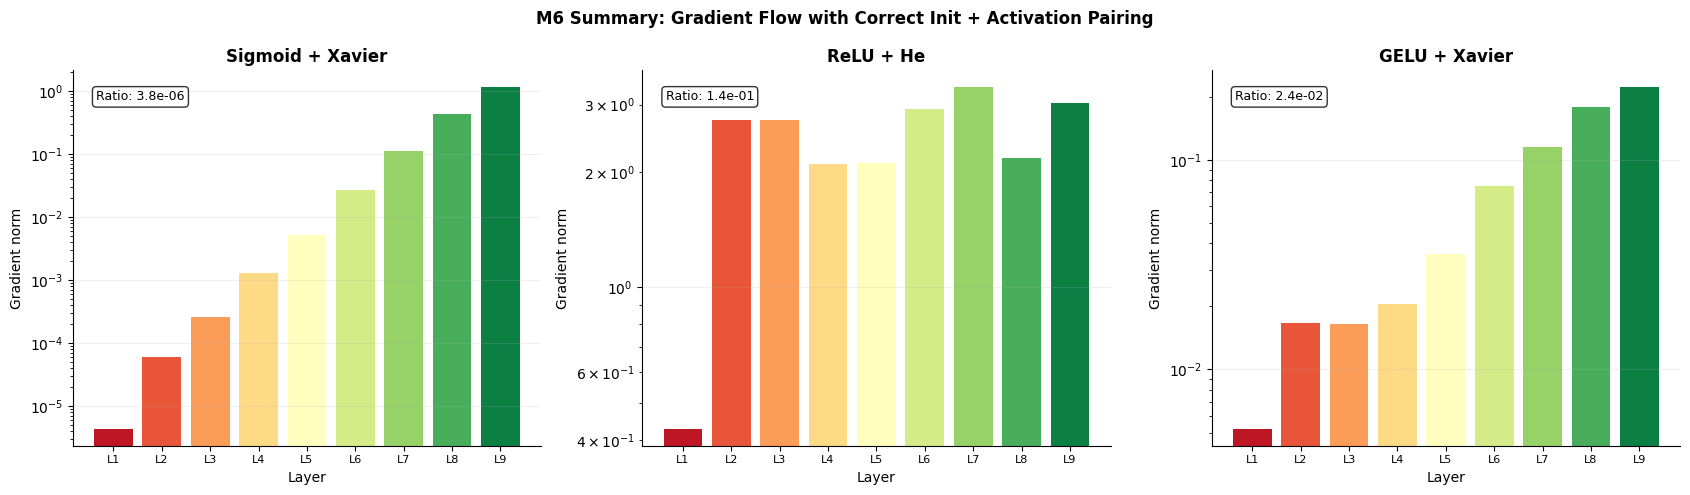

In [31]:
# --- Final gradient flow comparison with proper inits ---

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

configs_final = {
    'Sigmoid + Xavier': (nn.Sigmoid(), 'xavier'),
    'ReLU + He':        (nn.ReLU(),    'he'),
    'GELU + Xavier':    (nn.GELU(),    'xavier'),
}

for ax, (label, (act, init_scheme)) in zip(axes, configs_final.items()):
    torch.manual_seed(42)
    model = ClassifierNet(act, hidden=32, depth=8)
    for p in model.parameters():
        if p.dim() > 1:
            if init_scheme == 'he':
                nn.init.kaiming_normal_(p, nonlinearity='relu')
            else:
                nn.init.xavier_uniform_(p)

    norms = get_gradient_norms(model, X_sample, y_sample)
    values = list(norms.values())
    bar_colors = plt.cm.RdYlGn(np.linspace(0.05, 0.95, len(values)))
    ax.bar(range(len(values)), values, color=bar_colors)
    ax.set_yscale('log')
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels([f'L{i+1}' for i in range(len(values))], fontsize=8)
    ax.set_title(f'{label}', fontweight='bold')
    ax.set_xlabel('Layer'); ax.set_ylabel('Gradient norm')
    ax.grid(True, alpha=0.2, axis='y')
    ratio = values[0] / (values[-1] + 1e-12)
    ax.text(0.05, 0.92, f'Ratio: {ratio:.1e}', transform=ax.transAxes,
            fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.suptitle('M6 Summary: Gradient Flow with Correct Init + Activation Pairing',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()